For Overview of the Project.
This project performs Exploratory Data Analysis (EDA) on an insurance dataset to understand the factors affecting medical insurance charges. 
The analysis includes data cleaning, visualization, correlation analysis, and group-based comparisons.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("4956348-insurance (2).csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')

In [ ]:
df['sex'].value_counts()
df['smoker'].value_counts()
df['region'].value_counts()

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Charges vs Smoker")

plt.savefig("smoker.png", dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

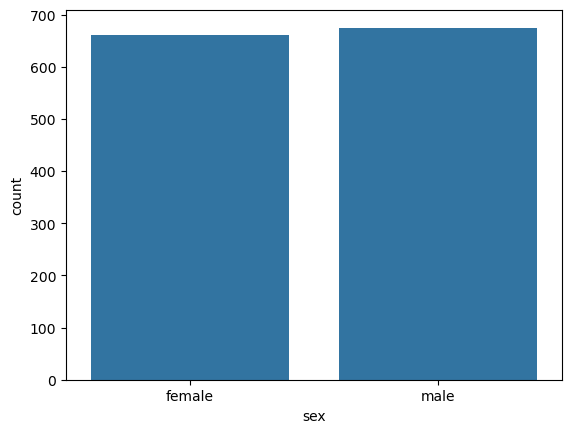

In [ ]:
sns.countplot(x='sex', data=df)
plt.show()

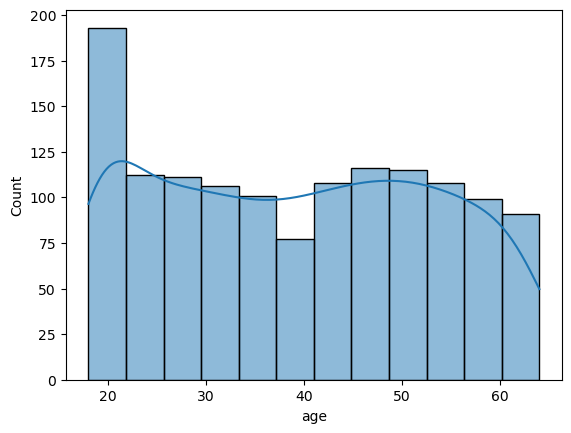

In [ ]:
sns.histplot(df['age'], kde=True)
plt.show()

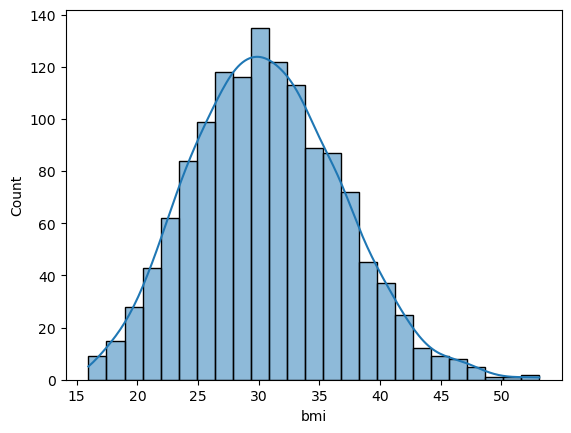

In [ ]:
sns.histplot(df['bmi'], kde=True)
plt.show()

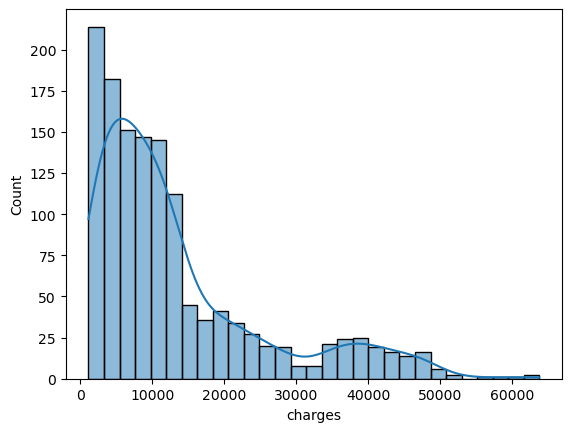

In [ ]:
sns.histplot(df['charges'], kde=True)
plt.show()

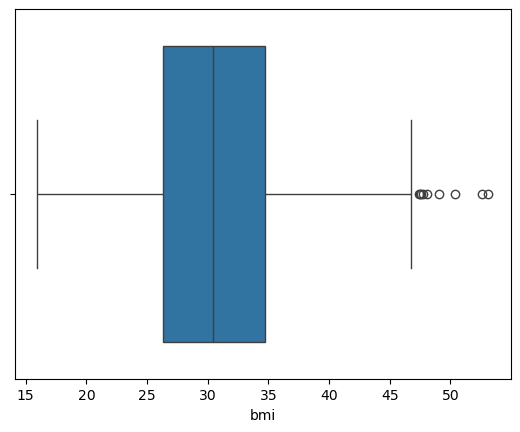

In [ ]:
sns.boxplot(x=df['bmi'])
plt.show()

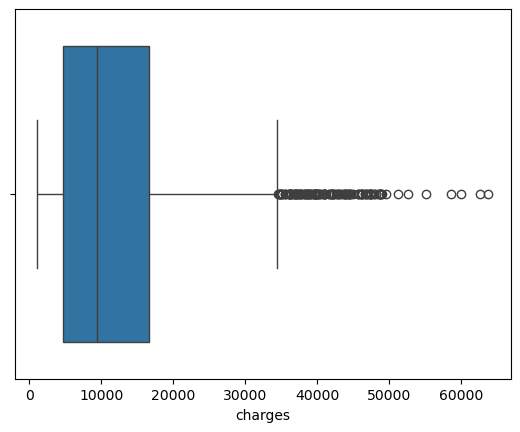

In [ ]:
sns.boxplot(x=df['charges'])
plt.show()

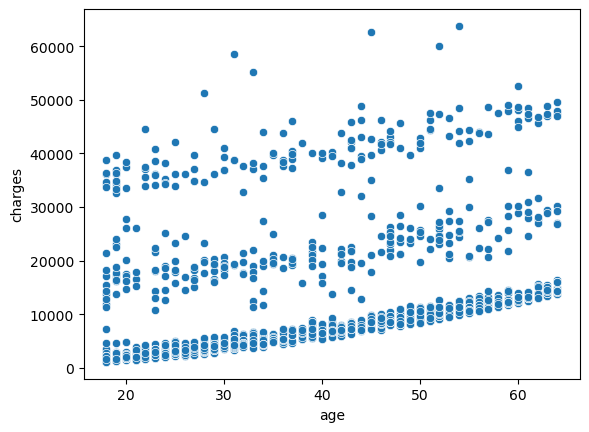

In [ ]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

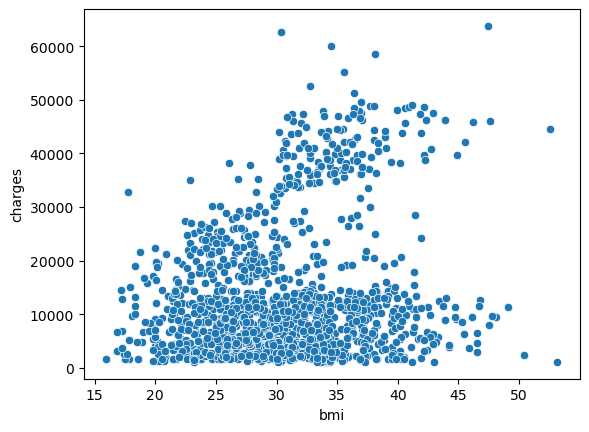

In [ ]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

In [ ]:
df.groupby('smoker')['charges'].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12380\1502497882.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('smoker')['charges'].mean()


smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

In [ ]:
df.groupby('sex')['charges'].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12380\1622073737.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['charges'].mean()


sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

In [ ]:
df.groupby('region')['charges'].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12380\1567564690.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('region')['charges'].mean()


region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [ ]:
df.groupby('children')['charges'].mean()

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

In [ ]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


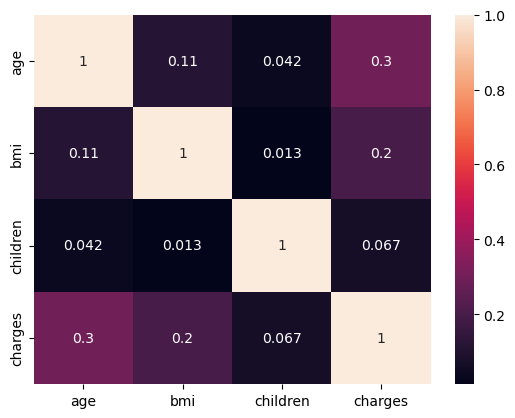

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df.sort_values(by='charges', ascending=False).head()

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209


In [ ]:
df[df['smoker'] == 'yes'].head()
df[df['charges'] > 50000]

,age,sex,bmi,children,smoker,region,charges
34,28,male,36.400,1,yes,southwest,51194.55914
543,54,female,47.410,0,yes,southeast,63770.42801
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
1230,52,male,34.485,3,yes,northwest,60021.39897
1300,45,male,30.360,0,yes,southeast,62592.87309


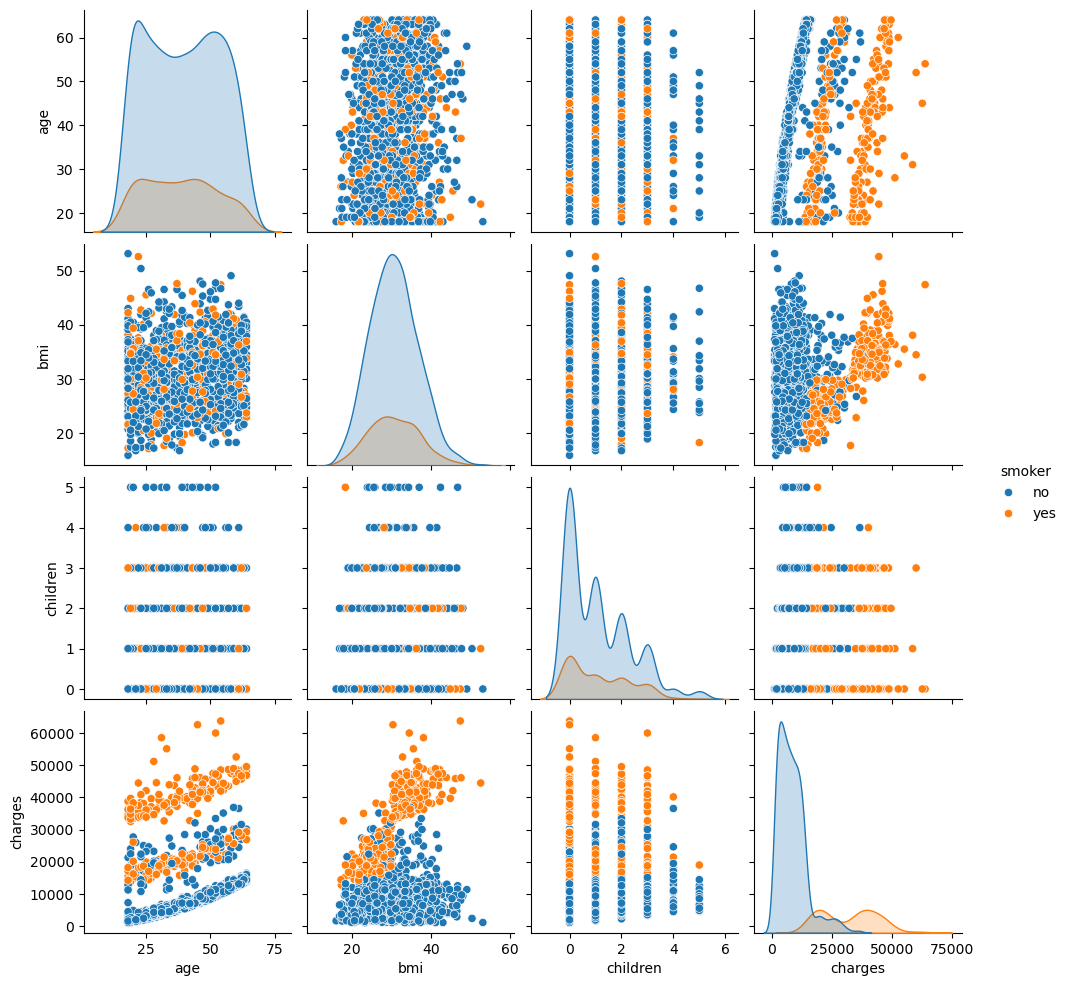

In [ ]:
sns.pairplot(df, hue='smoker')
plt.show()

In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4177.04556103632
MSE: 35478020.67523562
R2 Score: 0.8069287081198011


Conclusion:The insurance dataset was analyzed using data preprocessing, exploratory data analysis, and machine learning techniques.
Smoking was identified as the most significant factor influencing insurance charges, followed by age and BMI.
A Linear Regression model was built to predict charges, achieving an R² score of 0.80, demonstrating strong predictive performance. 
Overall, lifestyle factors play a major role in determining medical insurance costs.